# <font color='dark'>**Detecção de texto em placas de carro**</h1>

# <font color='dark'>**Aula 1**</h1>

### Instalação do tesseract

Necessário instalar o tesseract na máquina. Como o Colab utiliza um computador com sistema operacional Linux, é preciso utilizar o comando `!sudo apt install tesseract-ocr`.

Informação disponível na [documentação do tesseract](https://tesseract-ocr.github.io/tessdoc/Installation.html)

Na mesma documentação é possível ver as linguagens disponíveis no [github](https://github.com/tesseract-ocr/tessdata). Para utilizar a língua portuguesa, precisamos usar o arquivo `por.tessdata`

In [1]:
!sudo apt install tesseract-ocr

Reading package lists... Done
Building dependency tree       
Reading state information... Done
tesseract-ocr is already the newest version (4.00~git2288-10f4998a-2).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'sudo apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


Para usar o tesseract com a linguagem python, devemos instalar o pacote `pytesseract`, disponível no [PyPI](https://pypi.org/project/pytesseract/).

In [2]:
!pip install pytesseract

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Podemos baixar diretamente o arquivo `por.tessdata` do [github](https://github.com/tesseract-ocr/tessdata) ou baixar diretamente para o Google Colab com o comando `wget`.

In [3]:
!mkdir tessdata

In [4]:
!wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true

--2022-09-02 12:33:29--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 192.30.255.112
Connecting to github.com (github.com)|192.30.255.112|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/main/por.traineddata [following]
--2022-09-02 12:33:29--  https://github.com/tesseract-ocr/tessdata/raw/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/main/por.traineddata [following]
--2022-09-02 12:33:30--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

### Importação das bibliotecas

In [5]:
import cv2
import pytesseract

In [6]:
cv2.__version__

'4.6.0'

In [7]:
pytesseract.__version__

'0.3.10'

### Leitura da imagem

In [8]:
imagem = cv2.imread('/content/trecho_livro.png')

In [9]:
from google.colab.patches import cv2_imshow

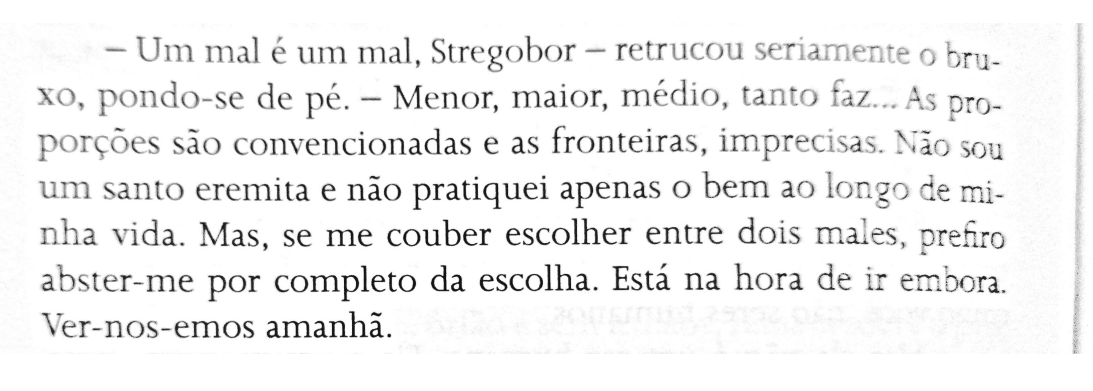

In [10]:
cv2_imshow(imagem)

In [11]:
texto = pytesseract.image_to_string(imagem)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente 0 bry.
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... A
porgdes sao convencionadas e as fronteiras, imprecisas.
um santo eremita e nao pratiquei apenas 0 bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro

abster-me por completo da escolha. Esta na hora de ir embora.
Ver-nos-emos amanha.

 

S pro-

40 SOU

 

 



In [12]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR.
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


In [13]:
config_tesseract = '--tessdata-dir tessdata --psm 6'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente o bry-
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... As pro-
porções são convencionadas e as fronteiras, imprecisas. Não sou
um santo eremita e não pratiquei apenas o bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro
abster-me por completo da escolha. Está na hora de ir embora. ;
Ver-nos-emos amanhã. |



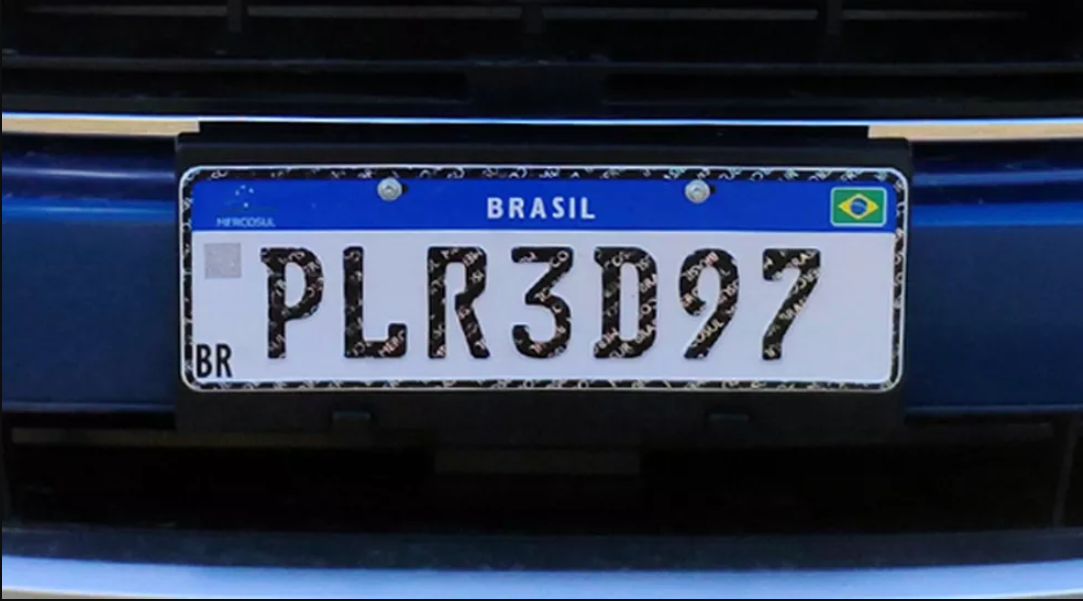

In [14]:
imagem = cv2.imread('/content/placa_carro1.png')
cv2_imshow(imagem)

A biblioteca opencv importa as imagens com os canais BGR, como pode ser visto na [documentação](https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html)

> **Note**

> *In the case of color images, the decoded images will have the channels stored in B G R order.*

O tesseract entende os canais na ordem RGB, portanto devemos fazer uma conversão da imagem de BGR para GRAY(escala de cinza), com o uso da função `cv2.cvtColor()`

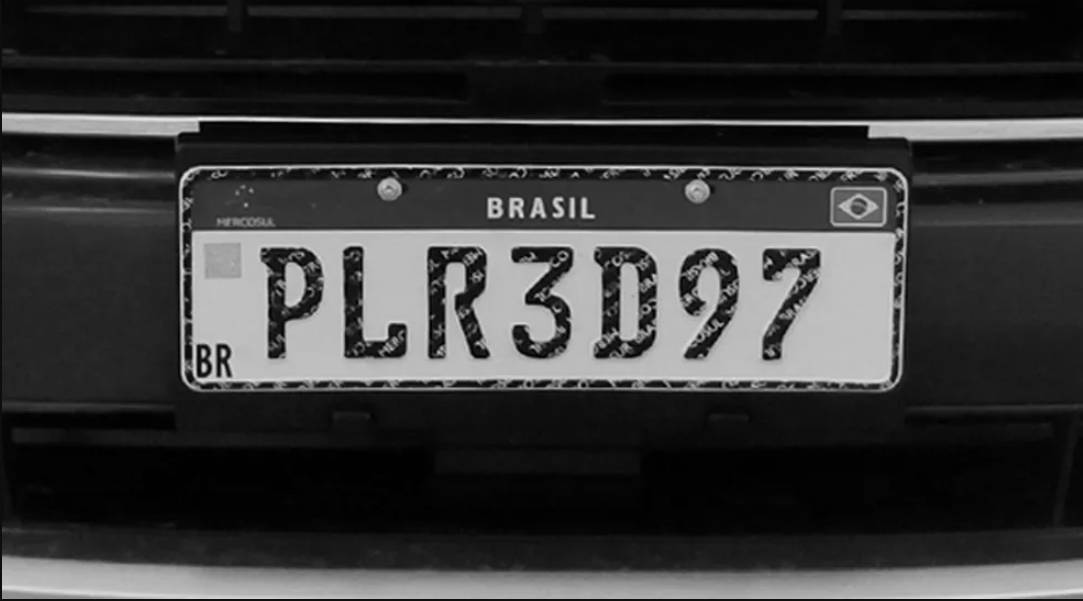

In [15]:
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
cv2_imshow(imagem)

In [16]:
config_tesseract = '--tessdata-dir tessdata'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

# <font color='dark'>**Aula 2**</h1>

Para conseguir realizar melhor a detecção dos textos contidos na imagem, podemos aplicar pré-processamentos na imagem a fim de deixar os caracteres mais destacados do restante da imagem.

Um desses pré-processamentos é a limiarização, que consiste em transformar a imagem totalmente para preto e branco.

- [Documentação OpenCV: Limiarização](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)

### Limiarização simples

![](https://i.imgur.com/9diya8F.gif)

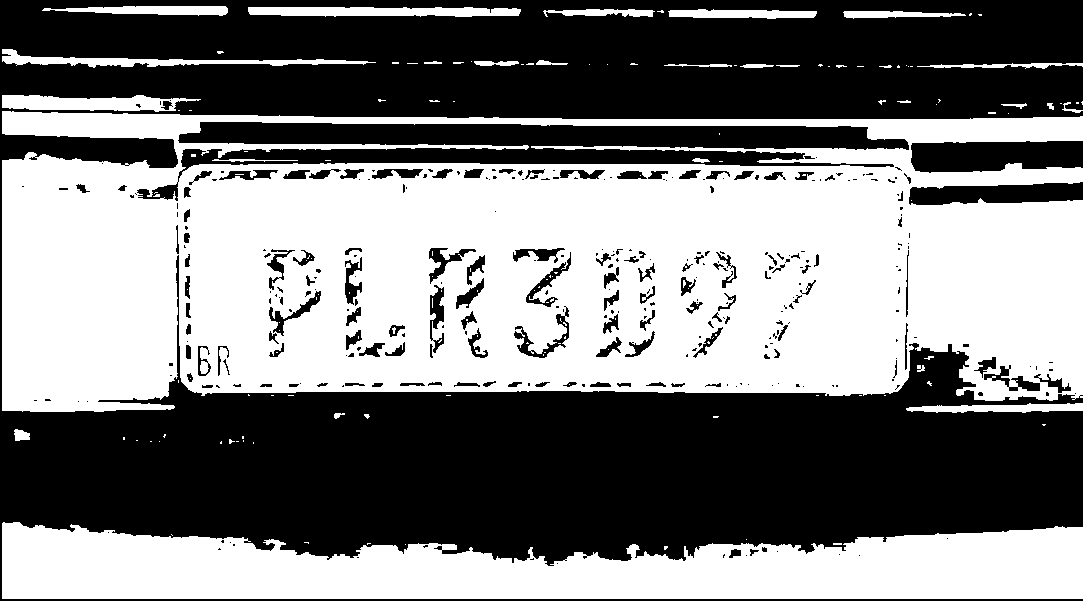

In [17]:
limiar = 25
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

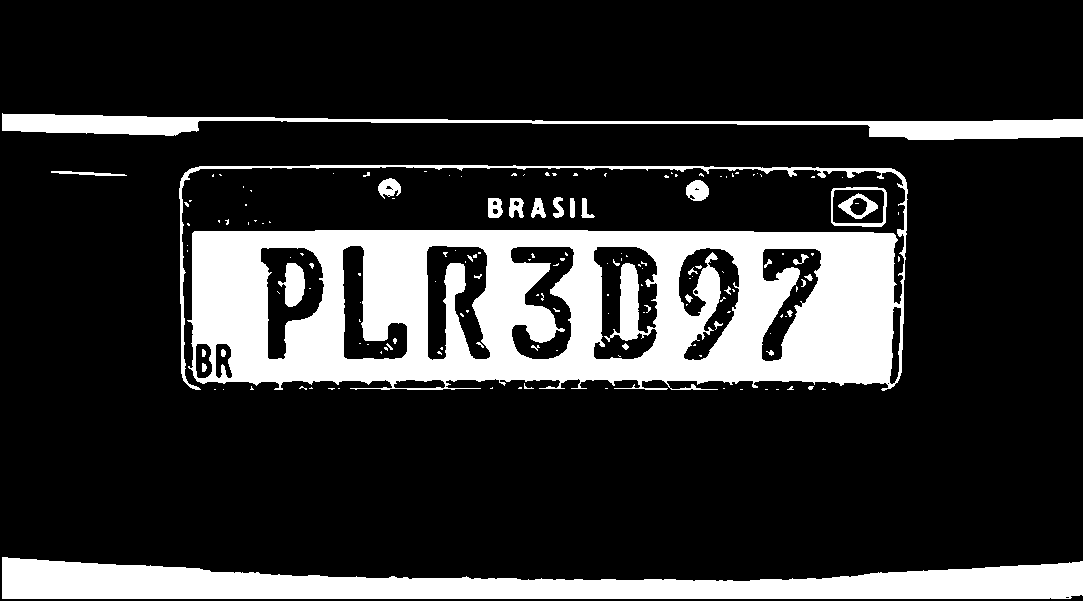

In [18]:
limiar = 127
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

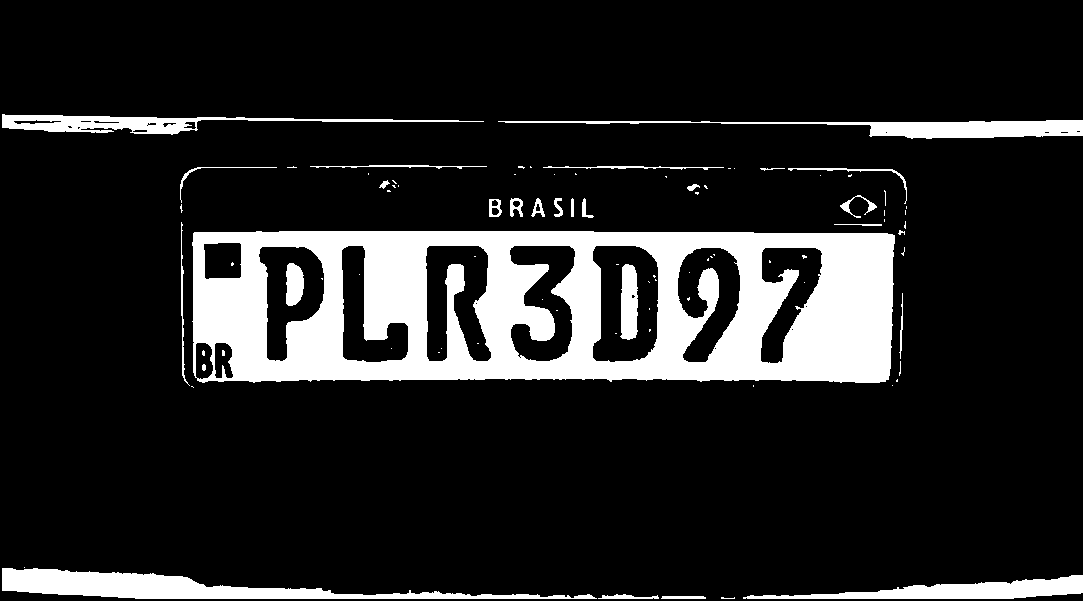

In [19]:
limiar = 170
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(lim_simples)

### Limiarização adaptativa

![](https://i.imgur.com/j6w6Rwu.gif)

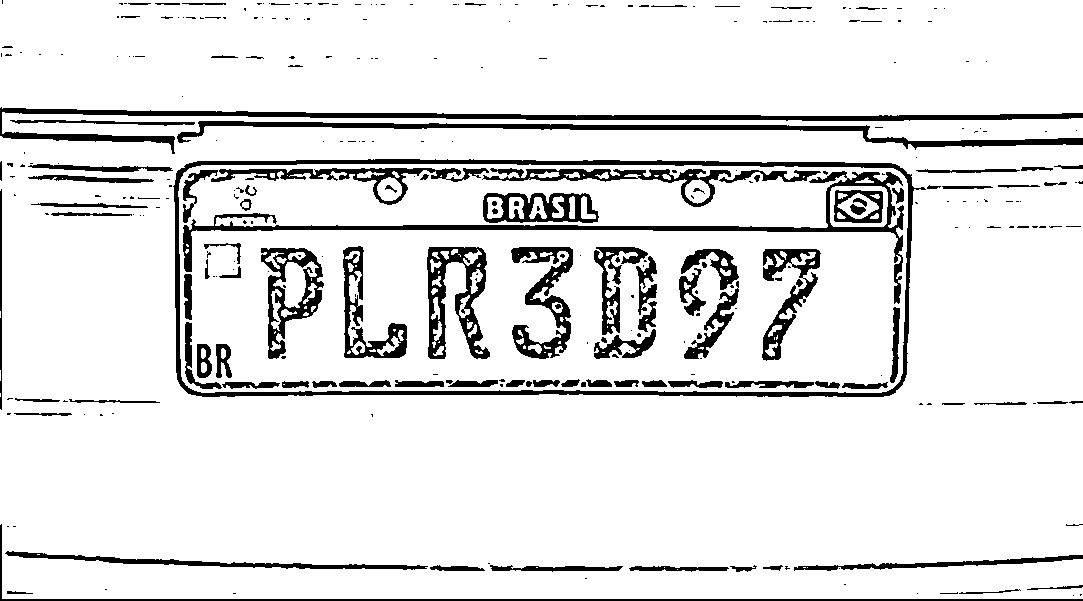

In [20]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

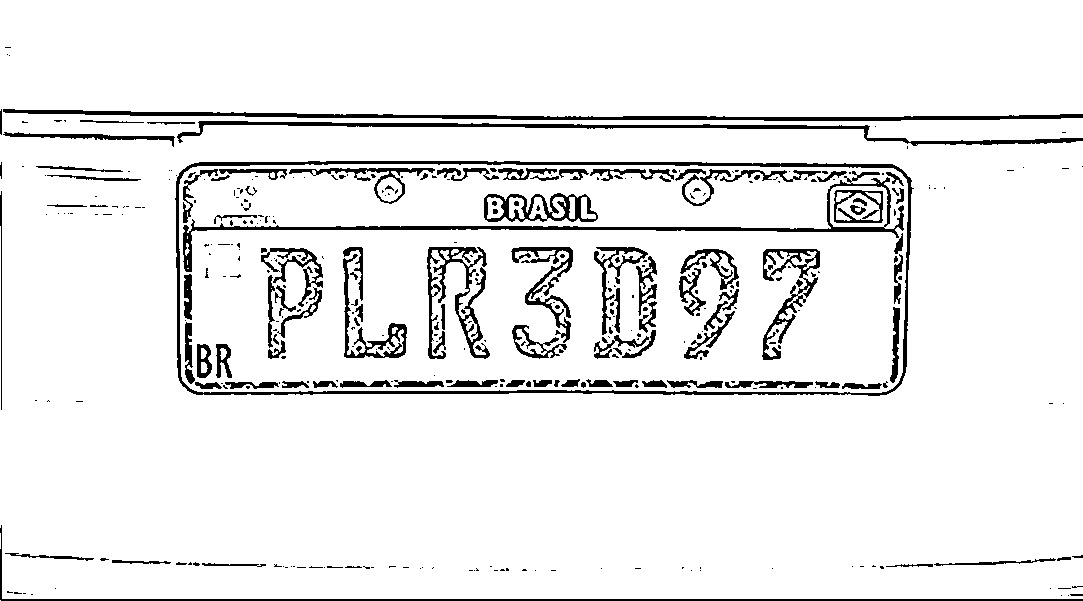

In [21]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

### Limiarização de Otsu

Podemos ver a intensidade de cor de uma imagem através de histogramas. A documentação do opencv sugere algumas formas de criar histogramas a partir de imagens:

- [Documentação OpenCV: Histogramas](https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html)

In [22]:
imagem

array([[ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   3, ...,   5,   5,   5],
       ...,
       [ 14,  14, 144, ..., 122, 121, 120],
       [ 14,  14,  14, ...,  14,  14,  14],
       [ 14,  14,  14, ...,  14,  14,  14]], dtype=uint8)

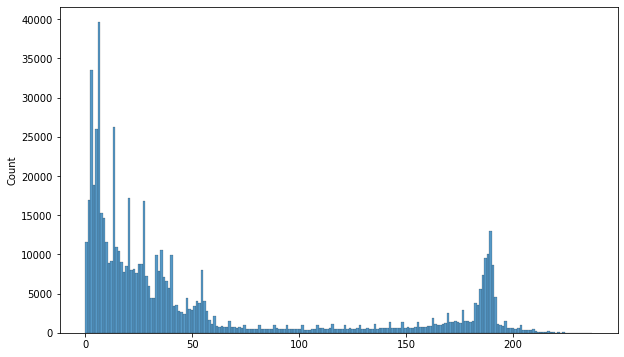

In [23]:
import seaborn as sns
ax = sns.histplot(imagem.flatten())
ax.figure.set_size_inches(10,6)

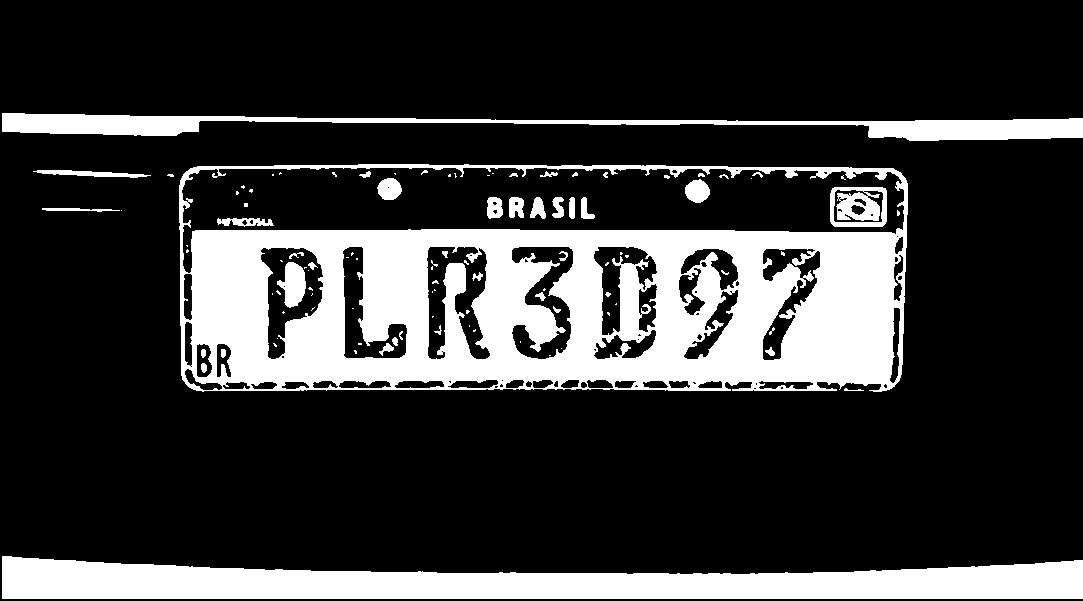

Limiar: 96.0


In [24]:
valor, lim_otsu = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(lim_otsu)
print(f'Limiar: {valor}')

In [25]:
config_tesseract = '--tessdata-dir tessdata'
texto = pytesseract.image_to_string(lim_otsu, lang = 'por', config = config_tesseract)
print(texto)

# <font color='dark'>**Aula 3**</h1>

É possível aplicar transformações na figura de forma a expandir, reduzir ou modificar a estrutura dos pixels da imagem a partir de um Kernel. São chamadas de transformações morfológicas.

As transformações morfológicas básicas são erosão e dilatação.

A partir delas são construídas as transformações de abertura, fechamento, gradiente, top hat (cartola) e black hat (chapéu preto).

- [Documentação OpenCV: Transformações Morfológicas](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)

In [26]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

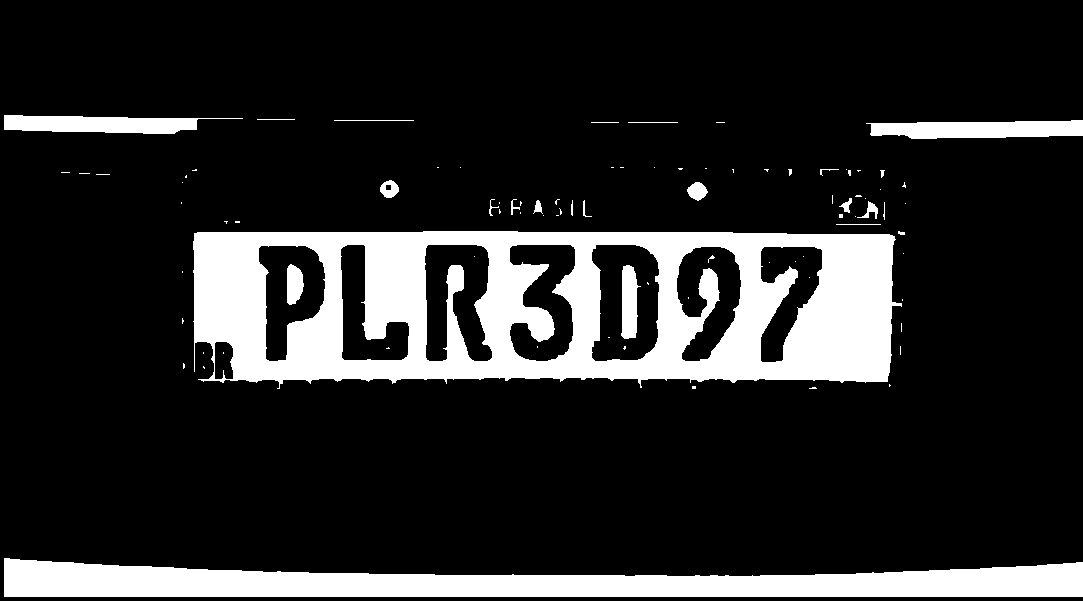

In [27]:
erosao = cv2.erode(lim_otsu,kernel)
cv2_imshow(erosao)

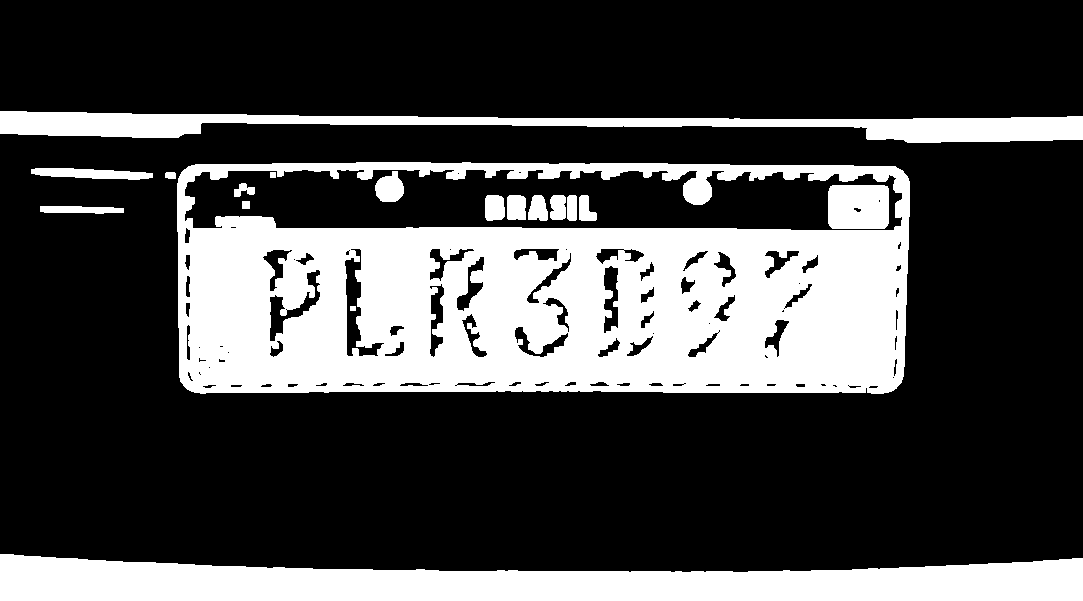

In [28]:
dilatacao = cv2.dilate(lim_otsu,kernel)
cv2_imshow(dilatacao)

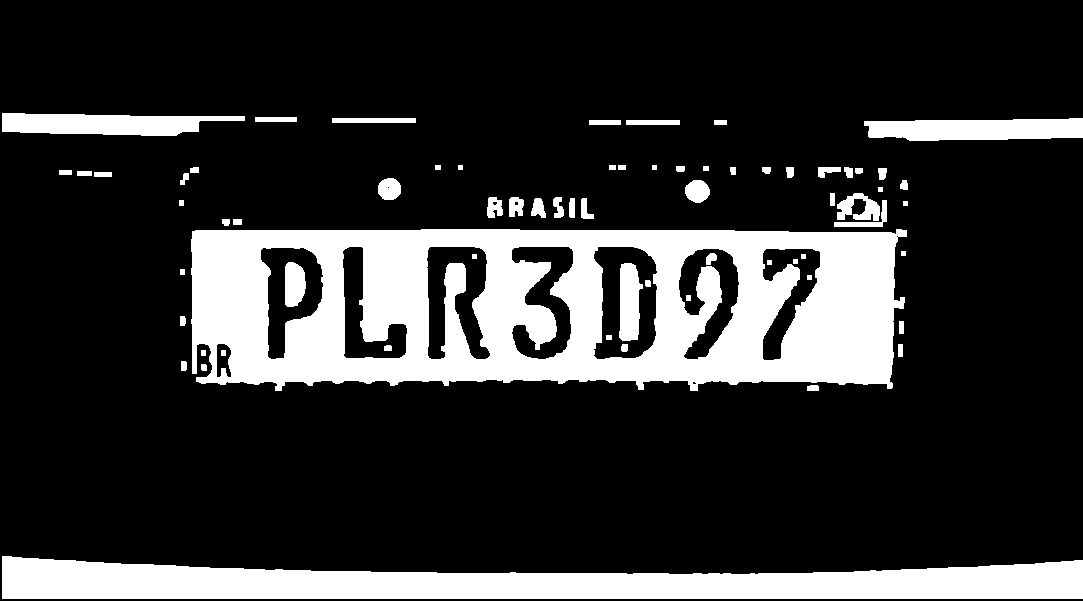

In [29]:
abertura = cv2.morphologyEx(lim_otsu, cv2.MORPH_OPEN, kernel)
cv2_imshow(abertura)

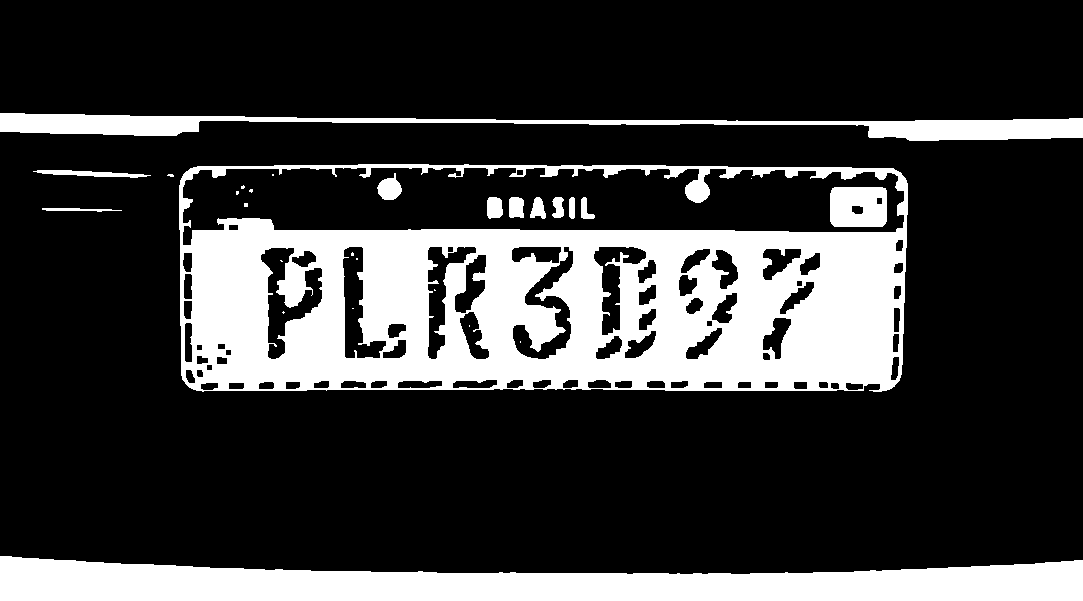

In [30]:
fechamento = cv2.morphologyEx(lim_otsu, cv2.MORPH_CLOSE, kernel)
cv2_imshow(fechamento)

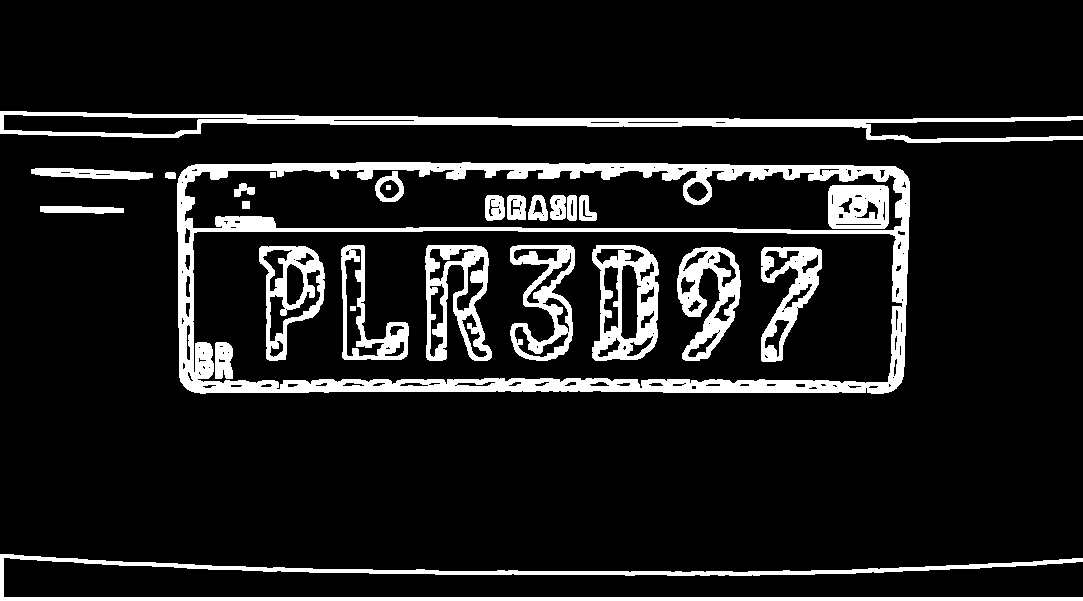

In [31]:
gradiente = cv2.morphologyEx(lim_otsu, cv2.MORPH_GRADIENT, kernel)
cv2_imshow(gradiente)

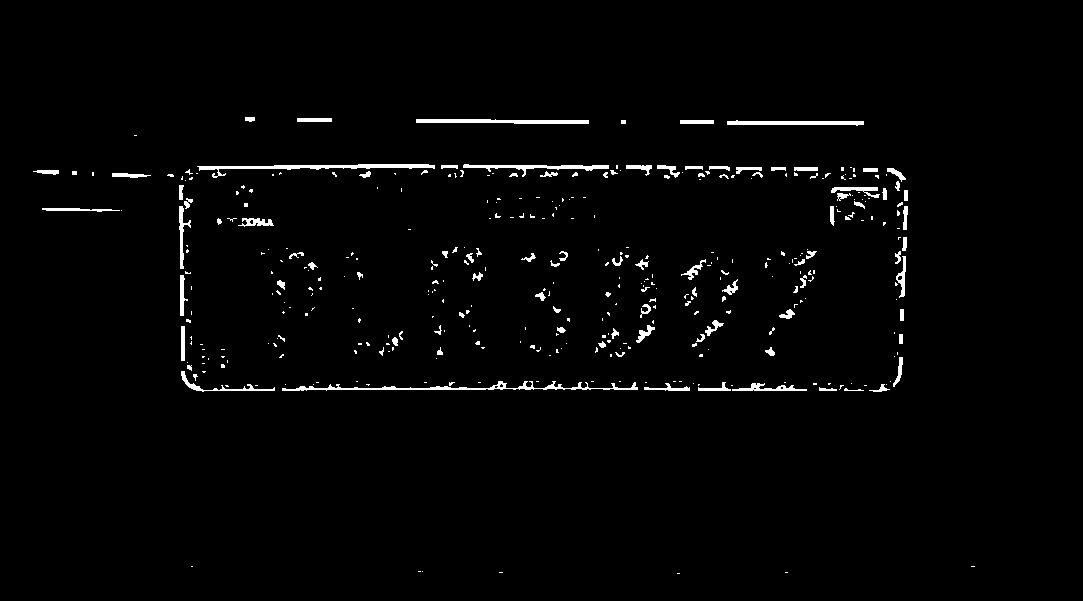

In [32]:
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel)
cv2_imshow(cartola)

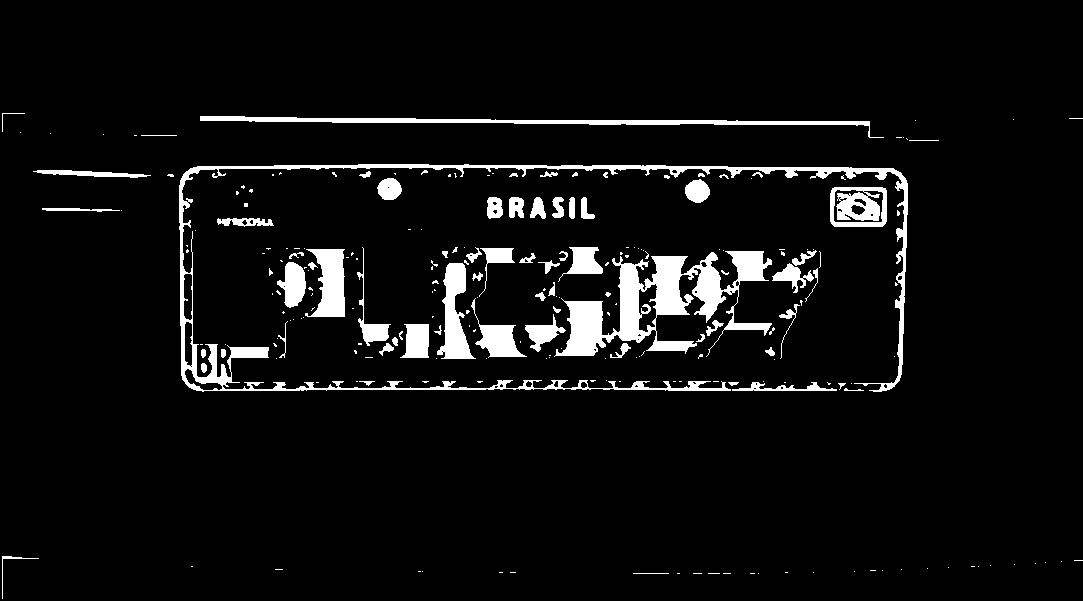

In [33]:
kernel_retangular = cv2.getStructuringElement(cv2.MORPH_RECT, (40,13))
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel_retangular)
cv2_imshow(cartola)

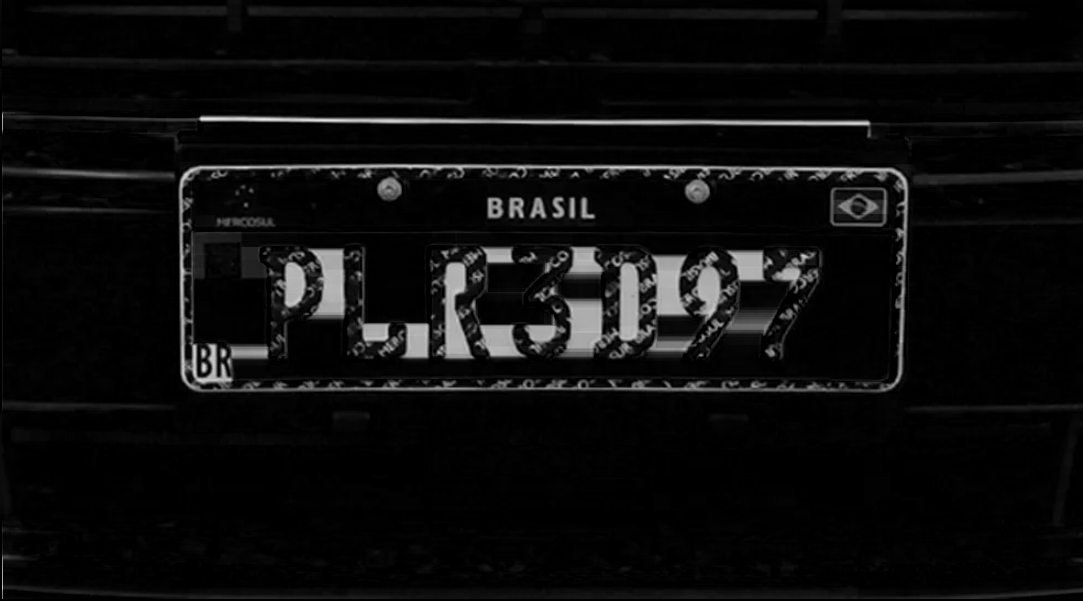

In [34]:
cartola = cv2.morphologyEx(imagem, cv2.MORPH_TOPHAT, kernel_retangular)
cv2_imshow(cartola)

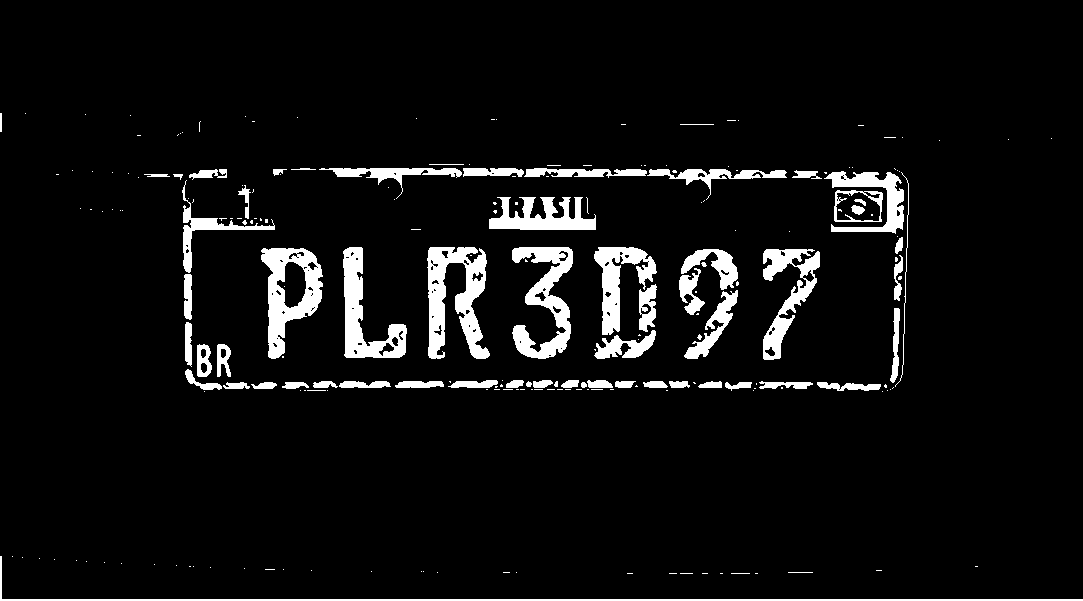

In [35]:
chapeu_preto = cv2.morphologyEx(lim_otsu, cv2.MORPH_BLACKHAT, kernel_retangular)
cv2_imshow(chapeu_preto)

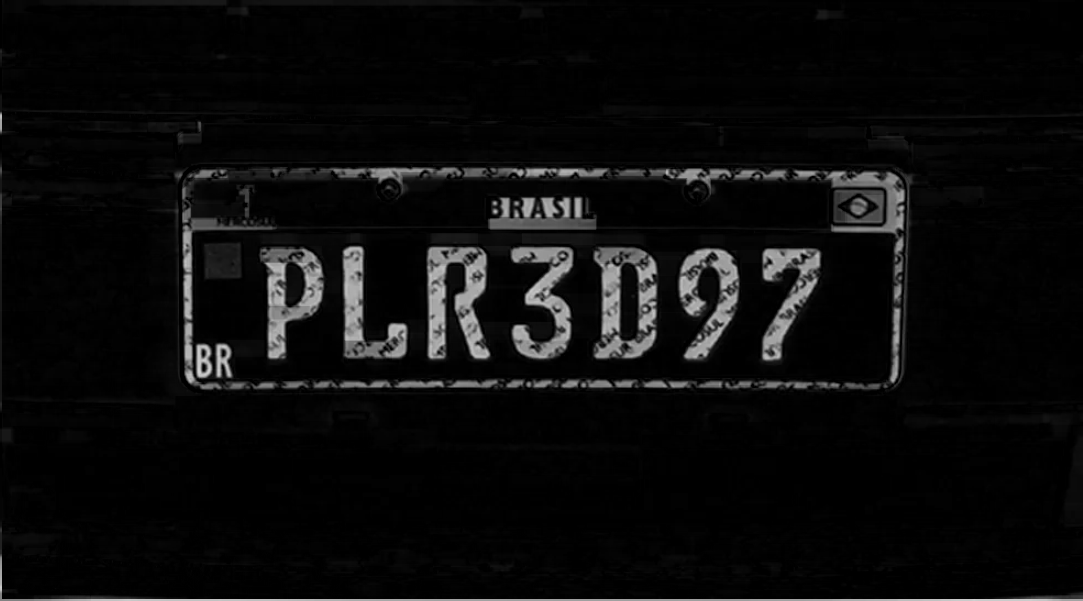

In [36]:
kernel_retangular = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 13))
chapeu_preto = cv2.morphologyEx(imagem, cv2.MORPH_BLACKHAT, kernel_retangular)
cv2_imshow(chapeu_preto)

In [37]:
config_tesseract = '--tessdata-dir tessdata --psm 6'
texto = pytesseract.image_to_string(erosao, lang = 'por', config = config_tesseract)
print(texto)

, PLRSD97 |
— :” NS ss



# <font color='dark'>**Aula 4**</h1>

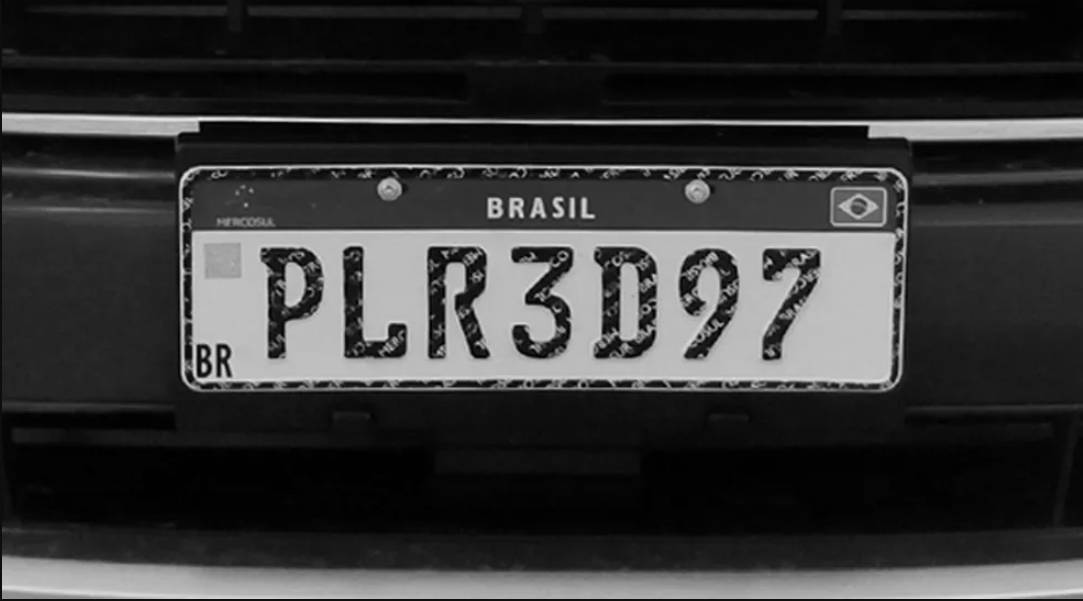

In [38]:
cv2_imshow(imagem)

Podemos detectar as bordas das imagens com o uso do método `Canny()`, através das bordas é possível encontrar a localização da placa, através dos contornos fechados em forma retangular.

- [Documentação OpenCV: Detector de bordas de Canny](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)

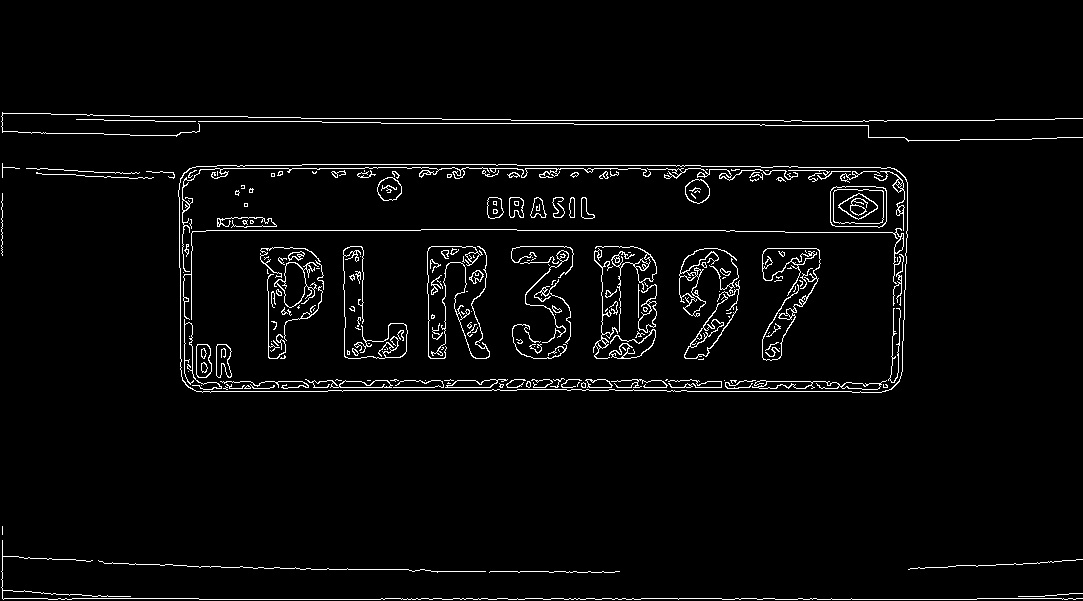

In [39]:
bordas = cv2.Canny(imagem, 100, 200) 
cv2_imshow(bordas)

Para detectar os contornos das placas, podemos usar o método `findContours()`.

- [Documentação OpenCV: Contornos](https://docs.opencv.org/4.x/d3/d05/tutorial_py_table_of_contents_contours.html)

In [40]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [41]:
contornos

(array([[[1069,  593]],
 
        [[1068,  594]],
 
        [[1057,  594]],
 
        [[1056,  595]],
 
        [[1045,  595]],
 
        [[1044,  596]],
 
        [[1018,  596]],
 
        [[1044,  596]],
 
        [[1045,  595]],
 
        [[1056,  595]],
 
        [[1057,  594]],
 
        [[1068,  594]],
 
        [[1069,  593]],
 
        [[1082,  593]]], dtype=int32), array([[[490, 571]],
 
        [[489, 572]],
 
        [[490, 571]],
 
        [[517, 571]],
 
        [[518, 572]],
 
        [[519, 572]],
 
        [[520, 571]],
 
        [[548, 571]],
 
        [[549, 572]],
 
        [[553, 572]],
 
        [[554, 571]],
 
        [[565, 571]],
 
        [[566, 572]],
 
        [[568, 572]],
 
        [[569, 571]],
 
        [[570, 572]],
 
        [[572, 572]],
 
        [[573, 571]],
 
        [[576, 571]],
 
        [[577, 572]],
 
        [[587, 572]],
 
        [[588, 571]],
 
        [[590, 571]],
 
        [[591, 572]],
 
        [[601, 572]],
 
        [[602, 571]],
 


In [42]:
for contorno in contornos:
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aproximacao = cv2.approxPolyDP(contorno, epsilon, True)
    if cv2.isContourConvex(aproximacao):
      if len(aproximacao) == 4:
          localizacao = aproximacao
          break

In [43]:
localizacao

array([[[180, 178]],

       [[196, 391]],

       [[901, 375]],

       [[894, 168]]], dtype=int32)

In [44]:
x, y, w, h = cv2.boundingRect(localizacao)

In [45]:
x

180

In [46]:
y

168

In [47]:
w

722

In [48]:
h

224

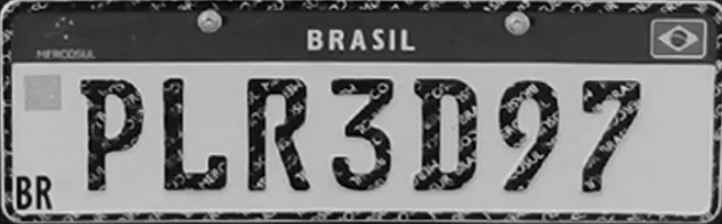

In [49]:
placa = imagem[y:y + h, x:x + w]
cv2_imshow(placa)

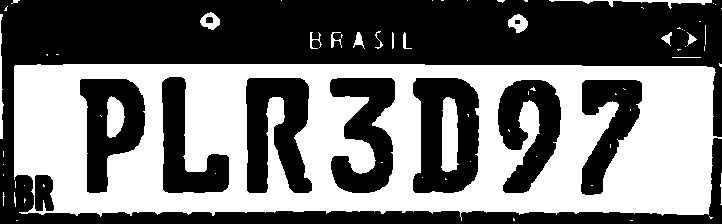

In [50]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
erosao = cv2.erode(lim_otsu, cv2.getStructuringElement(cv2.MORPH_RECT, (4,4)))
cv2_imshow(erosao)

In [51]:
config_tesseract = f'--tessdata-dir tessdata --psm 6'
texto = pytesseract.image_to_string(erosao, lang = 'por', config = config_tesseract)
print(texto)

L PLR3D97



In [52]:
import re
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

<re.Match object; span=(2, 9), match='PLR3D97'>

In [53]:
print(texto_extraido.group(0))

PLR3D97


### Aplicação em outro cenário

In [54]:
imagem = cv2.imread('/content/placa_carro2.jpg')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

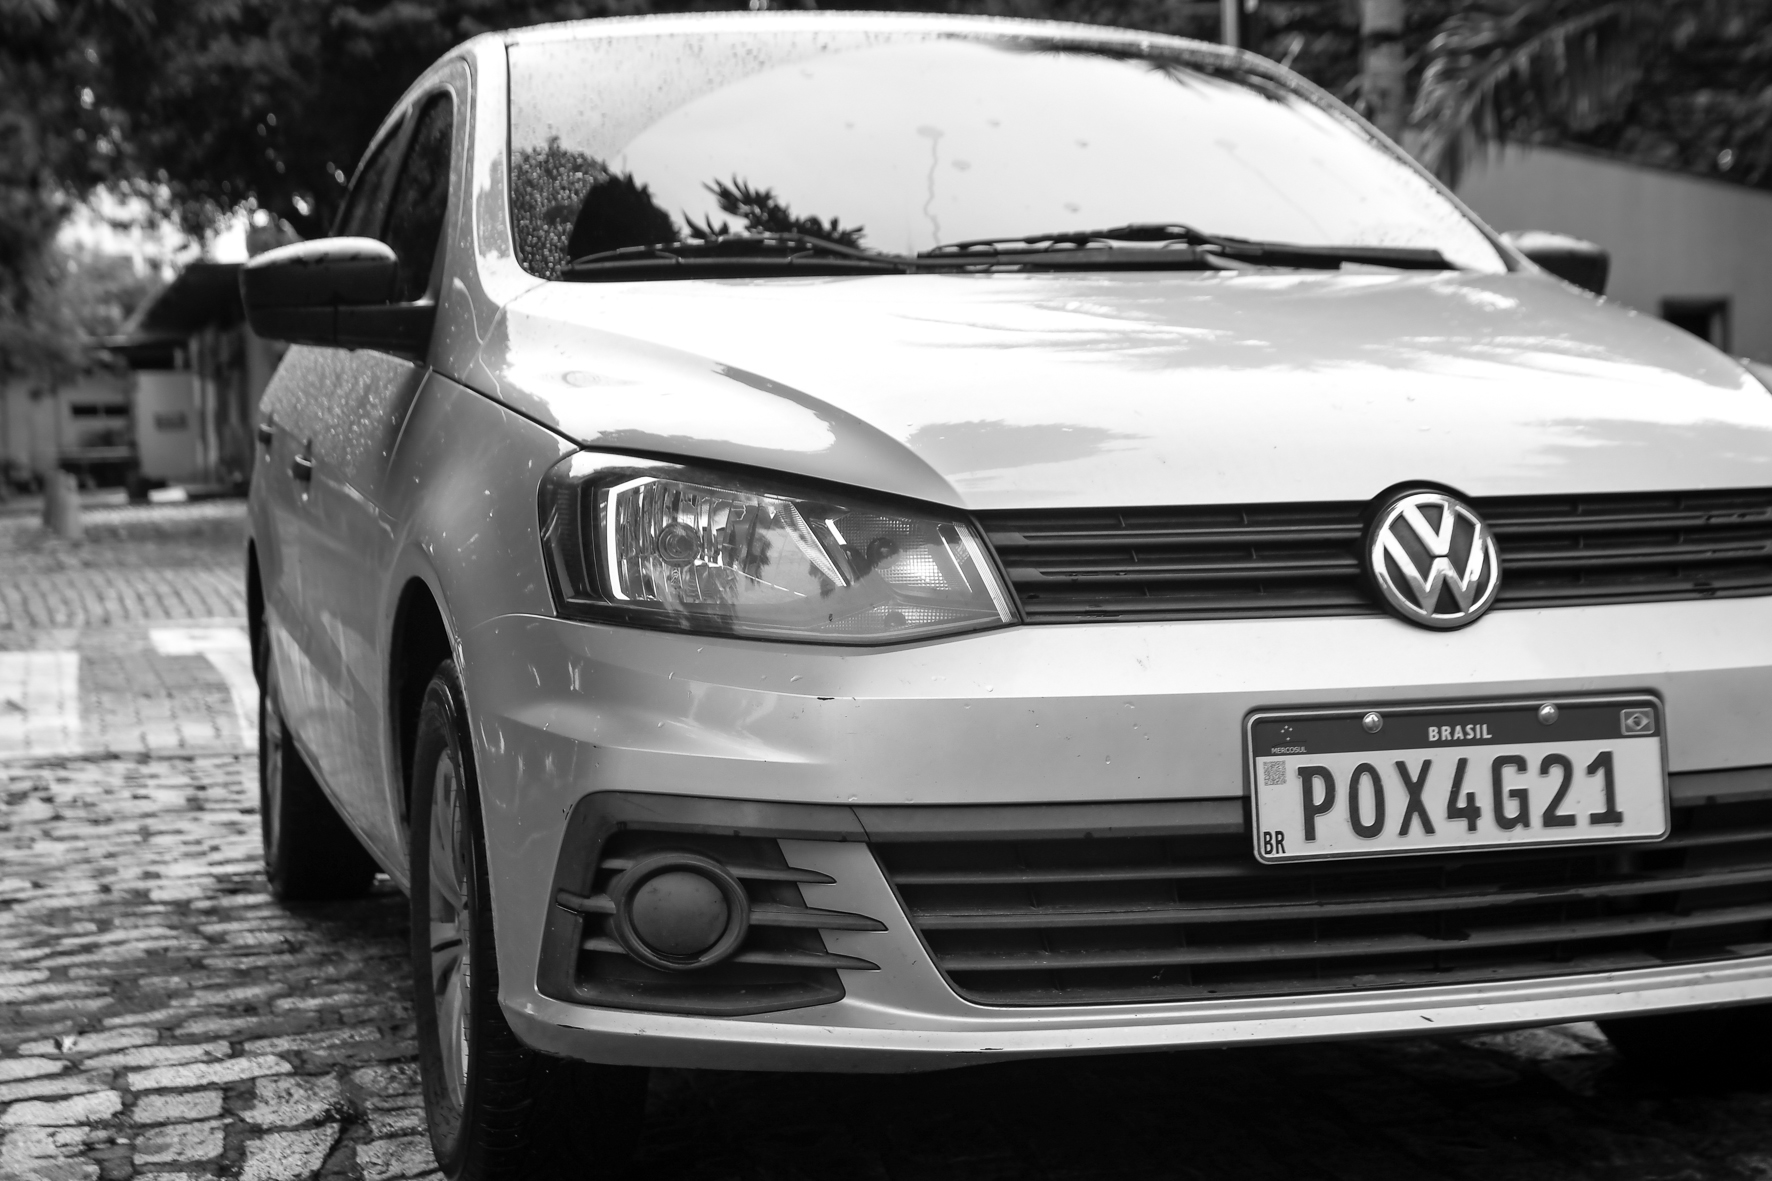

In [55]:
cv2_imshow(imagem)

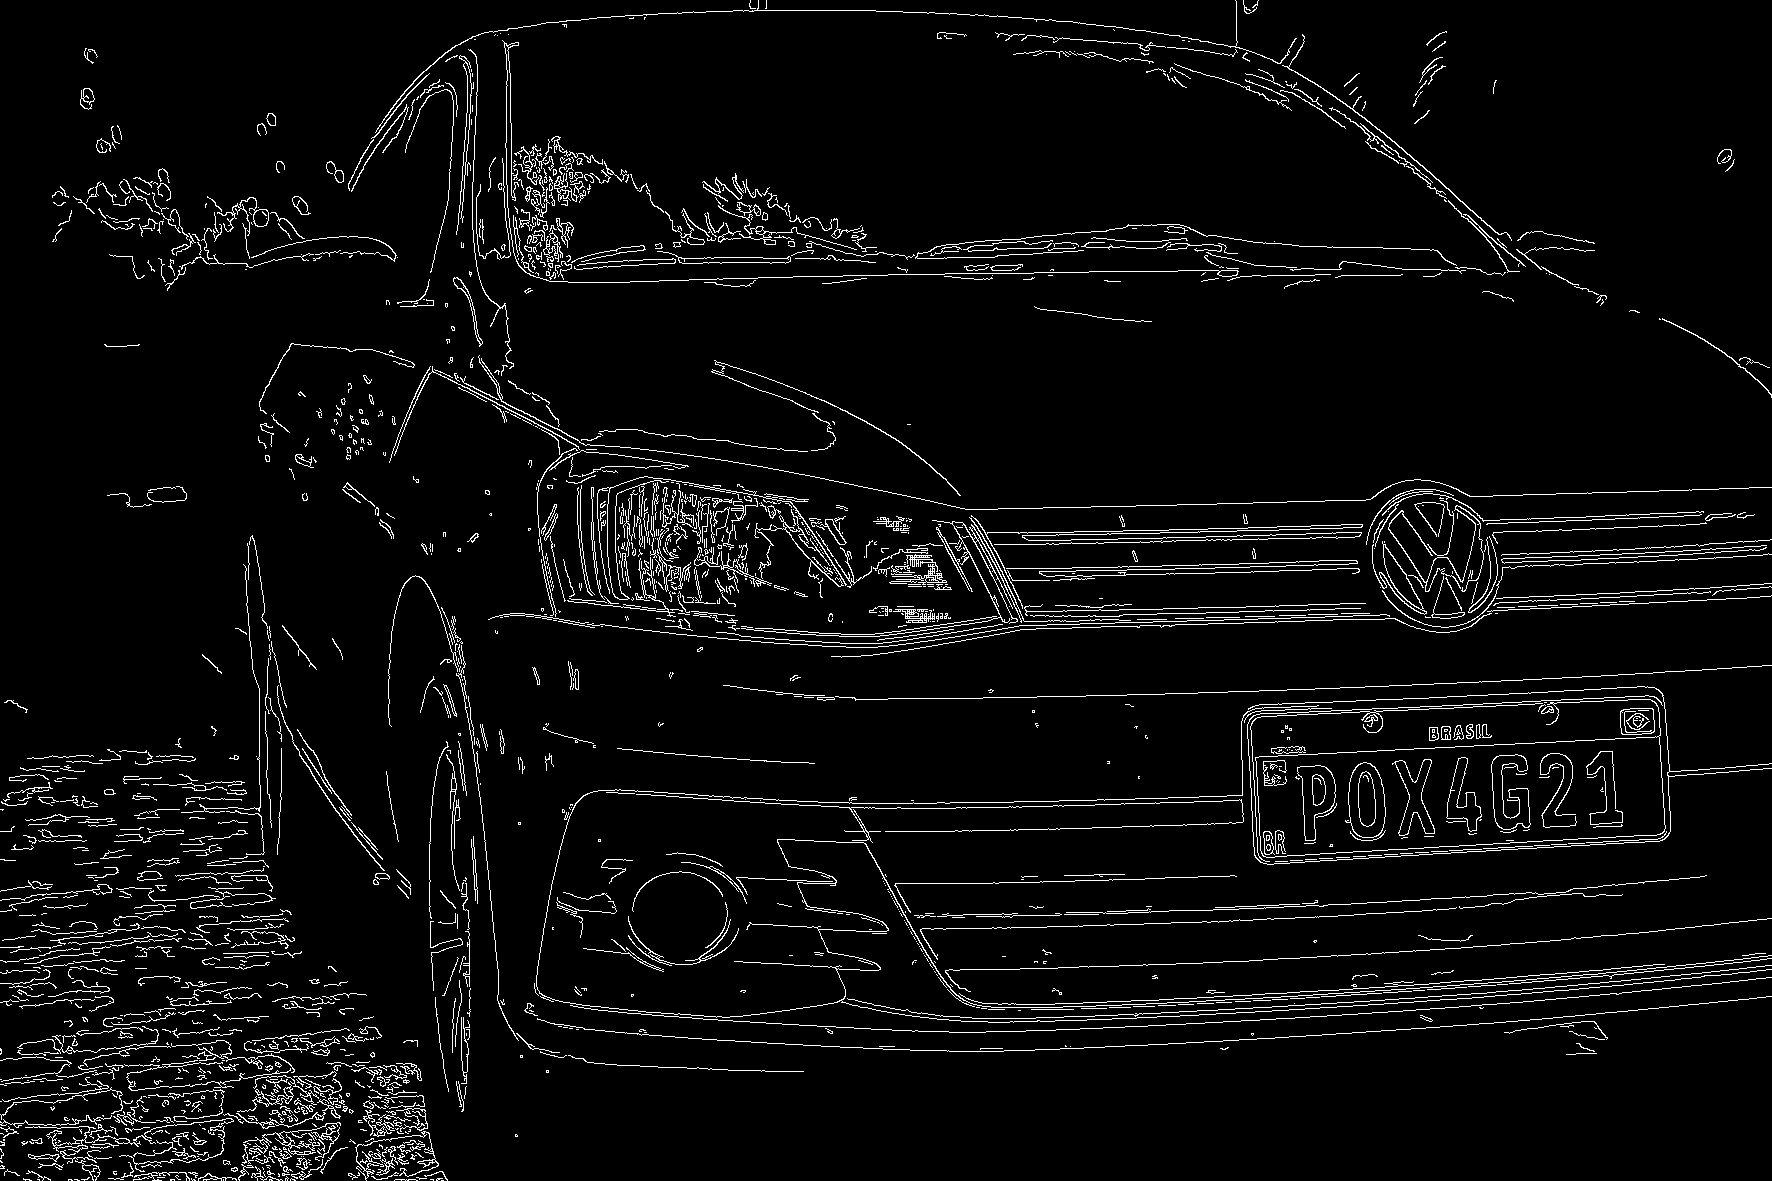

In [56]:
bordas = cv2.Canny(imagem, 100, 200)
cv2_imshow(bordas)

In [57]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key=cv2.contourArea, reverse=True)[:10]

In [58]:
for contorno in contornos:
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aproximacao = cv2.approxPolyDP(contorno, epsilon, True)
    if cv2.isContourConvex(aproximacao) and len(aproximacao) == 4:
        localizacao = aproximacao
        break

In [59]:
localizacao

array([[[1659,  737]],

       [[1656,  835]],

       [[1260,  850]],

       [[1259,  756]]], dtype=int32)

In [60]:
x, y, w, h = cv2.boundingRect(localizacao)

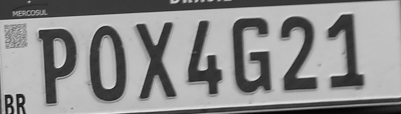

In [61]:
placa = imagem[y:y + h, x:x + w]
cv2_imshow(placa)

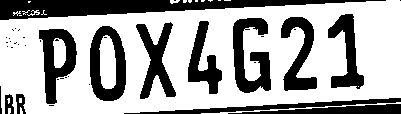

In [62]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(lim_otsu)

In [63]:
texto = pytesseract.image_to_string(lim_otsu, lang = 'por', config = config_tesseract)
print(texto)

“POX4G21



In [64]:
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

<re.Match object; span=(1, 8), match='POX4G21'>

In [65]:
print(texto_extraido.group(0))

POX4G21


# <font color='dark'>**Aula 5**</h1>


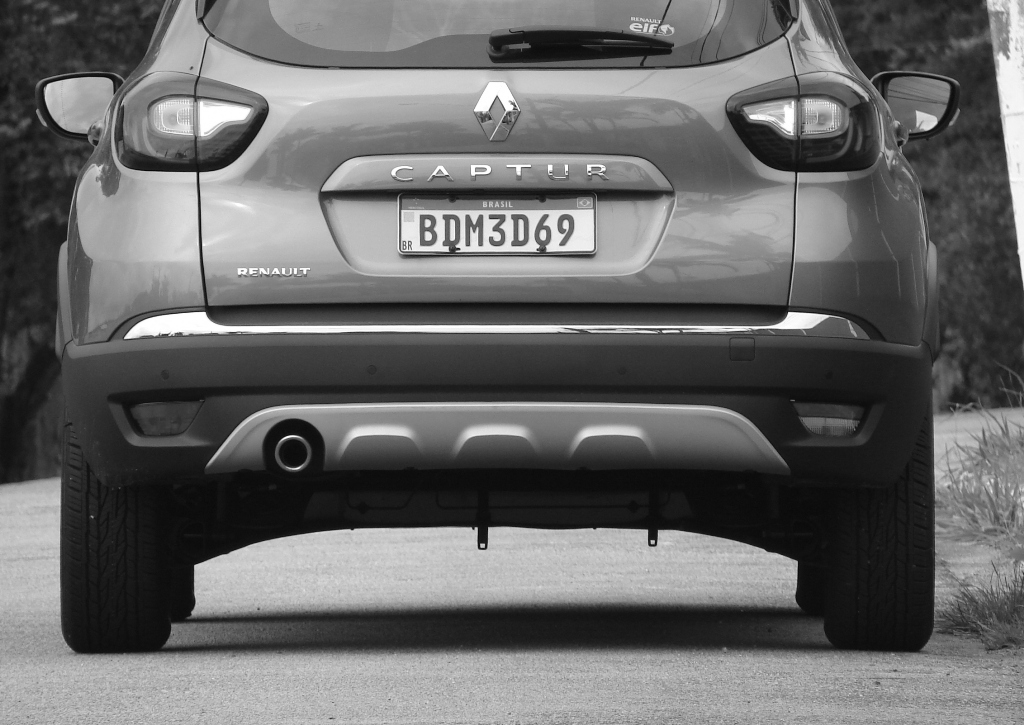

In [66]:
imagem = cv2.imread('/content/placa_carro3.jpg')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
cv2_imshow(imagem)

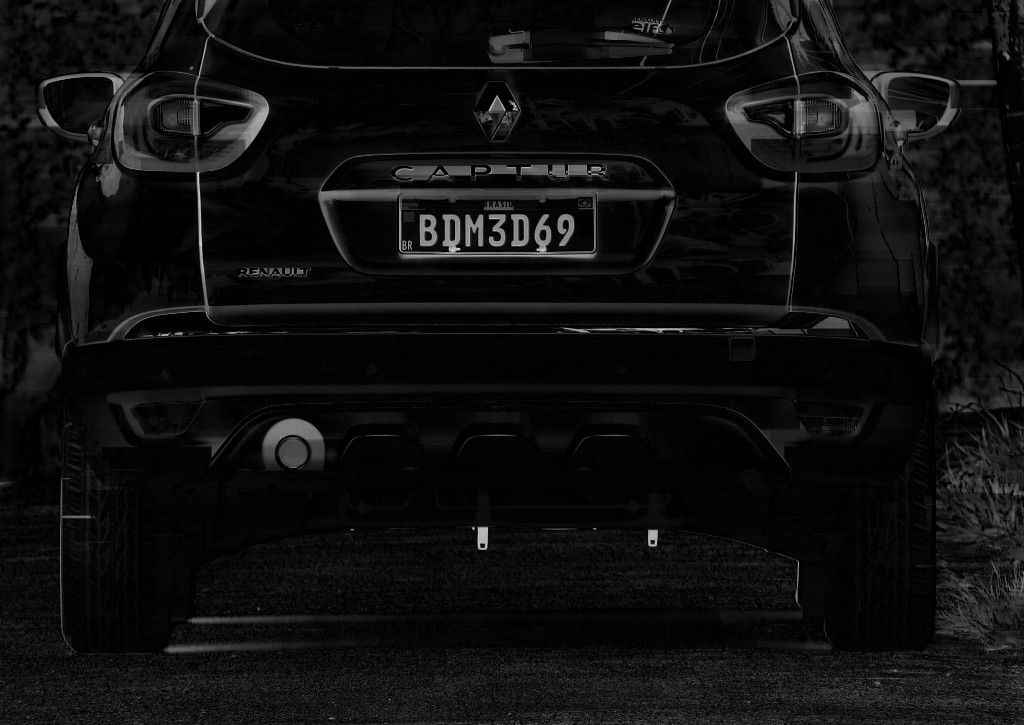

In [67]:
kernel_retangular = cv2.getStructuringElement(cv2.MORPH_RECT, (40,13))
chapeu_preto = cv2.morphologyEx(imagem, cv2.MORPH_BLACKHAT, kernel_retangular)
cv2_imshow(chapeu_preto)

- [Documentação OpenCV: Sobel](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gacea54f142e81b6758cb6f375ce782c8d)

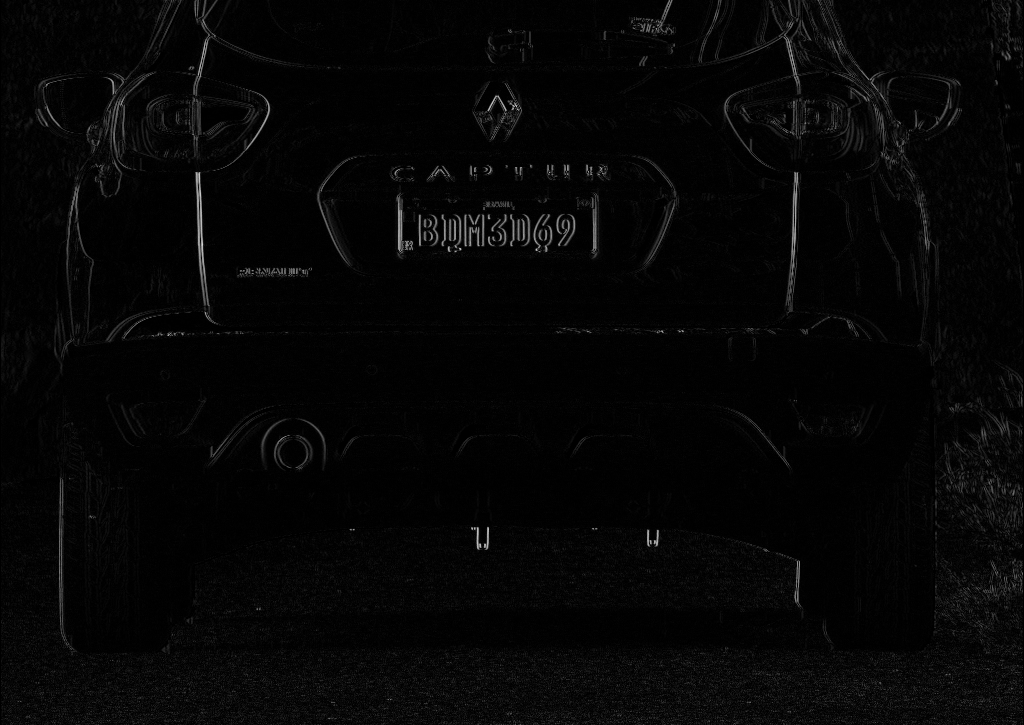

In [68]:
import numpy as np

sobel_x = cv2.Sobel(chapeu_preto, ddepth = cv2.CV_32F, dx = 1, dy = 0, ksize = 1)
sobel_x = np.absolute(sobel_x)
sobel_x = sobel_x.astype('uint8')
cv2_imshow(sobel_x)

- [Documentação OpenCV: GaussianBlur](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gaabe8c836e97159a9193fb0b11ac52cf1)

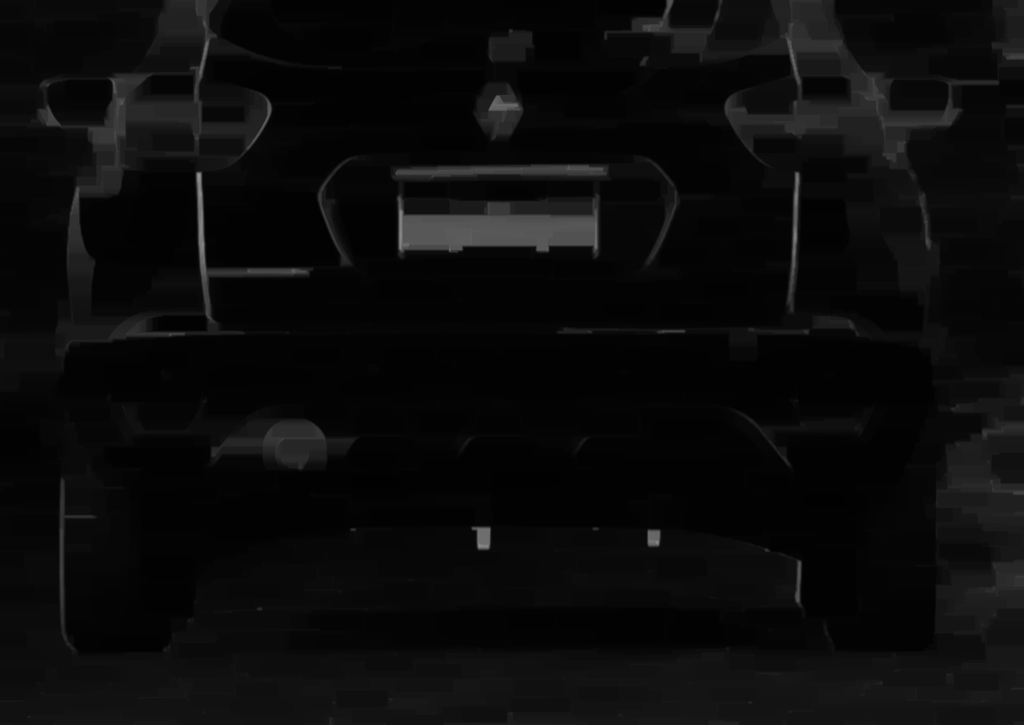

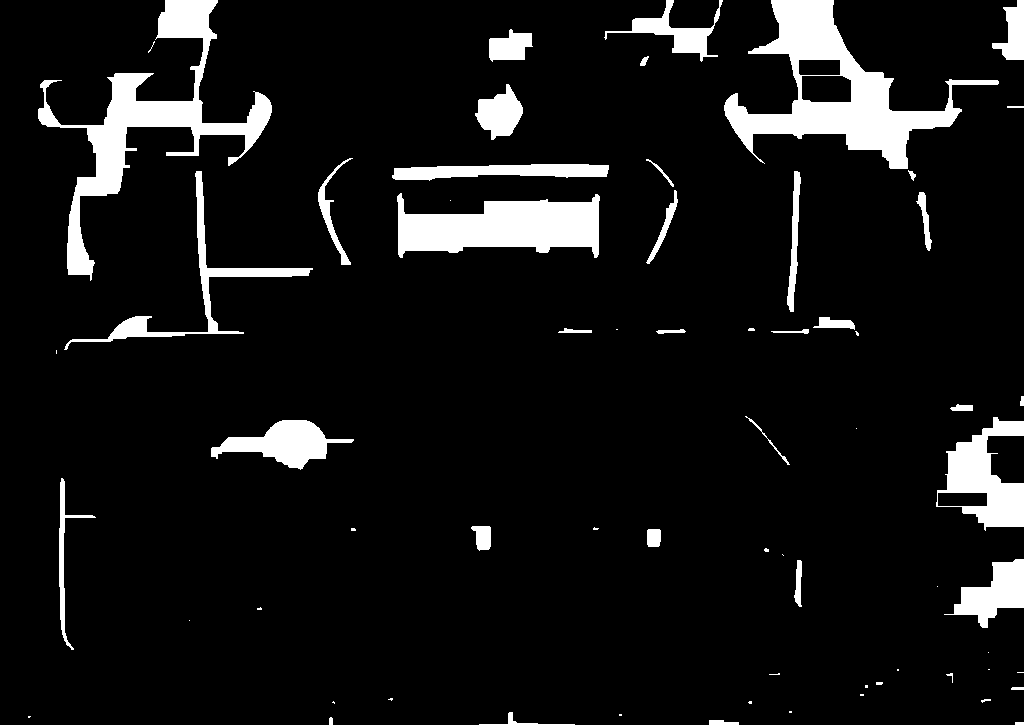

In [69]:
sobel_x= cv2.GaussianBlur(sobel_x, (5,5), 0)
sobel_x = cv2.morphologyEx(sobel_x, cv2.MORPH_CLOSE, kernel_retangular)
cv2_imshow(sobel_x)
valor, limiarizacao = cv2.threshold(sobel_x, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(limiarizacao)

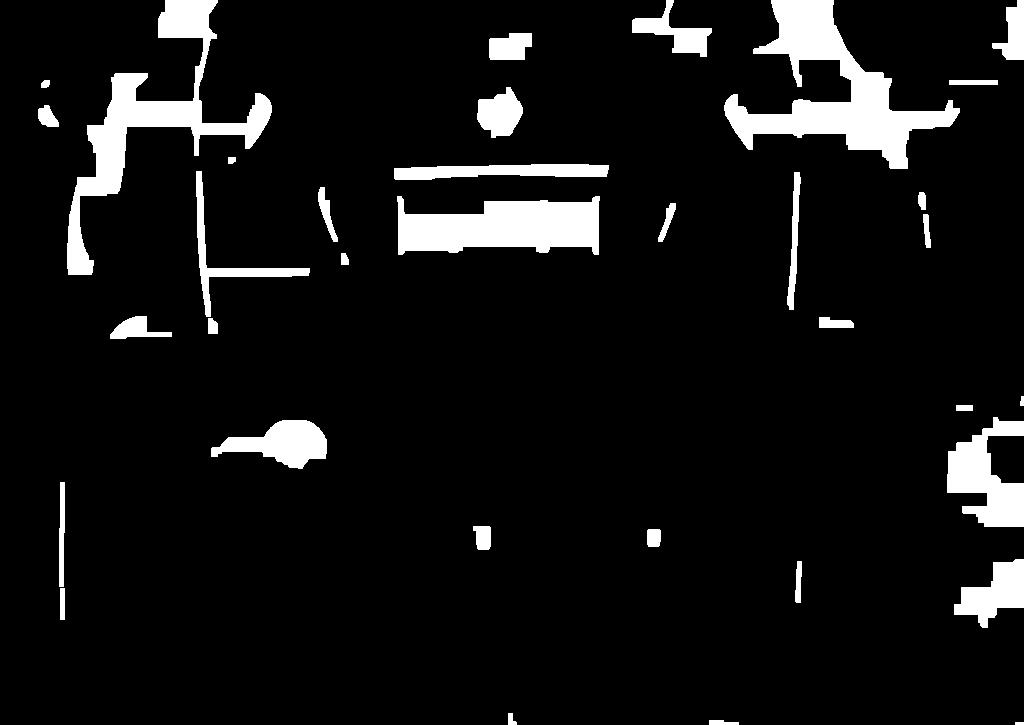

In [70]:
kernel_quadrado = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
limiarizacao = cv2.erode(limiarizacao, kernel_quadrado, iterations = 2)
limiarizacao = cv2.dilate(limiarizacao, kernel_quadrado, iterations = 2)
cv2_imshow(limiarizacao)

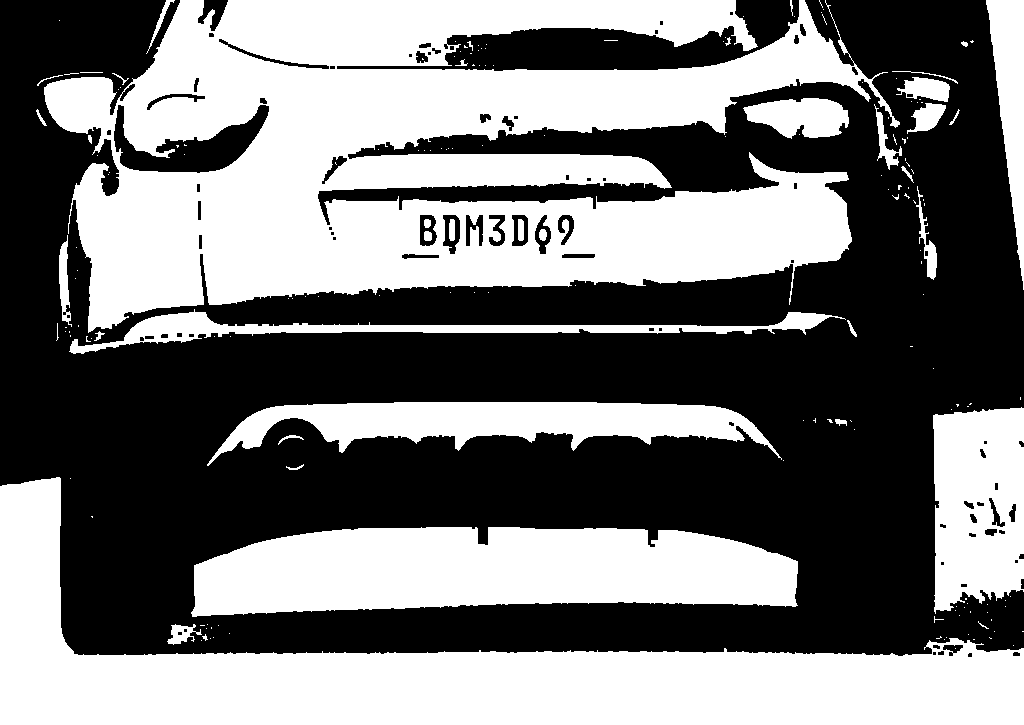

In [71]:
fechamento = cv2.morphologyEx(imagem, cv2.MORPH_CLOSE, kernel_quadrado)
valor, mascara = cv2.threshold(fechamento, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(mascara)

- [Documentação OpenCV: Bitwise and](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14)

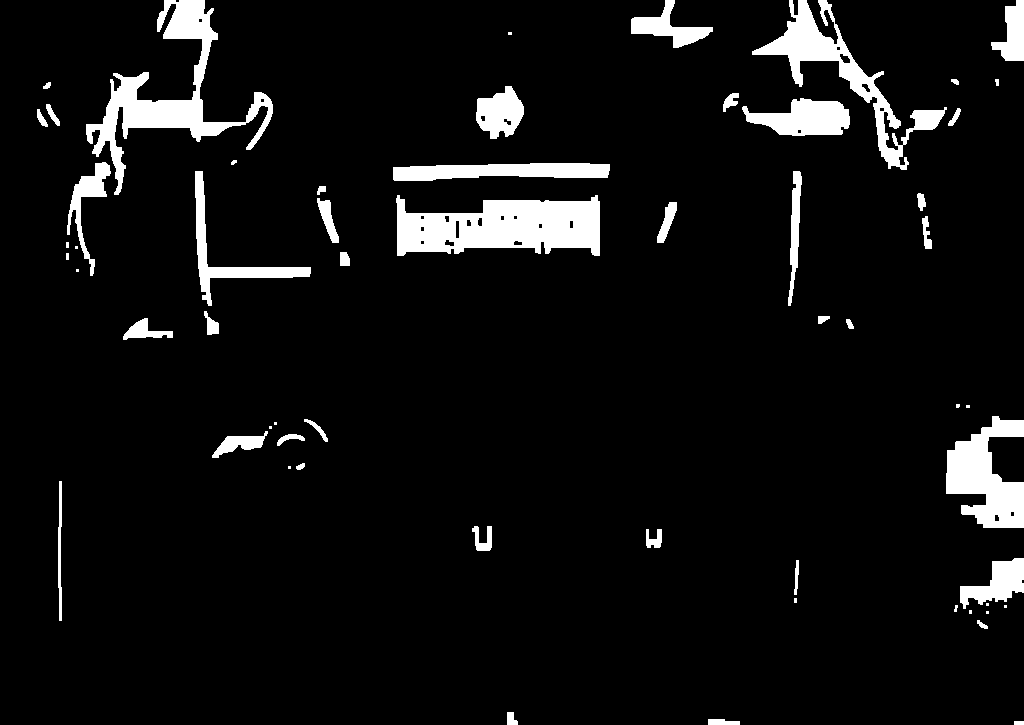

In [72]:
limiarizacao = cv2.bitwise_and(limiarizacao, limiarizacao, mask = mascara)
limiarizacao = cv2.dilate(limiarizacao, kernel_quadrado, iterations = 2)
limiarizacao = cv2.erode(limiarizacao, kernel_quadrado)
cv2_imshow(limiarizacao)

- [Documentação Scikit image: Clear Border](https://scikit-image.org/docs/dev/api/skimage.segmentation.html?highlight=clear+border#skimage.segmentation.clear_border)

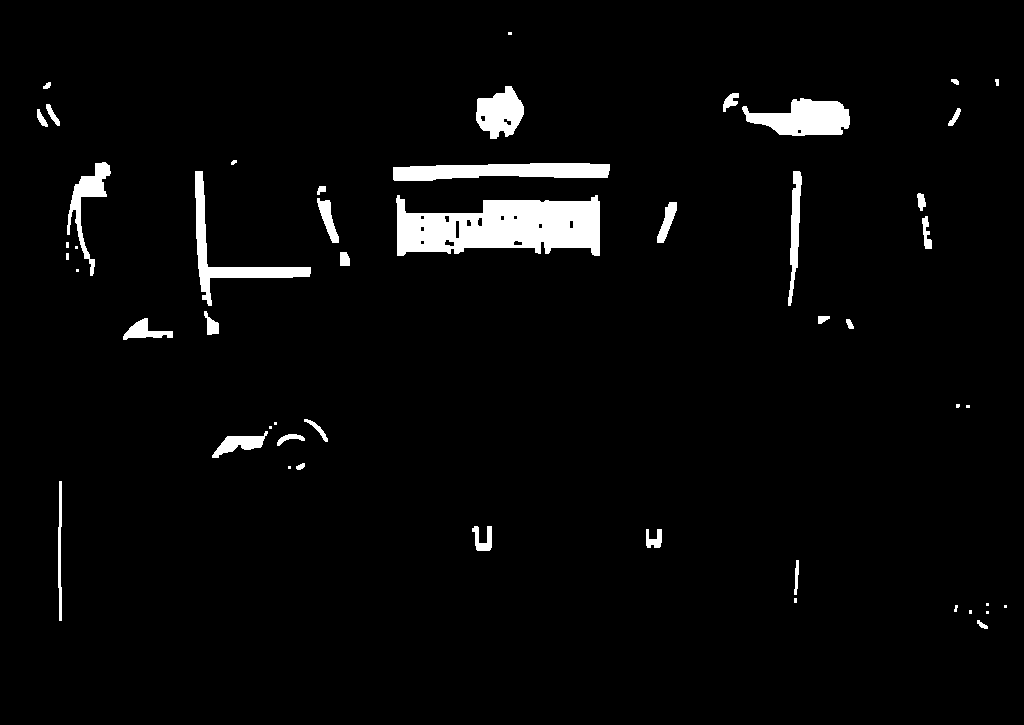

In [73]:
from skimage.segmentation import clear_border
limiarizacao = clear_border(limiarizacao)
cv2_imshow(limiarizacao)

In [74]:
contornos, hierarquia = cv2.findContours(limiarizacao, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key = cv2.contourArea, reverse = True)[:10]
contornos

[array([[[397, 195]],
 
        [[397, 197]],
 
        [[396, 198]],
 
        [[396, 202]],
 
        [[397, 203]],
 
        [[397, 255]],
 
        [[403, 255]],
 
        [[405, 253]],
 
        [[405, 252]],
 
        [[406, 251]],
 
        [[446, 251]],
 
        [[448, 253]],
 
        [[450, 253]],
 
        [[450, 249]],
 
        [[451, 248]],
 
        [[453, 248]],
 
        [[454, 249]],
 
        [[454, 253]],
 
        [[458, 253]],
 
        [[460, 251]],
 
        [[463, 251]],
 
        [[463, 248]],
 
        [[464, 247]],
 
        [[534, 247]],
 
        [[535, 248]],
 
        [[535, 252]],
 
        [[537, 252]],
 
        [[538, 253]],
 
        [[540, 253]],
 
        [[540, 242]],
 
        [[541, 241]],
 
        [[543, 241]],
 
        [[544, 242]],
 
        [[544, 247]],
 
        [[545, 248]],
 
        [[545, 253]],
 
        [[548, 253]],
 
        [[549, 252]],
 
        [[549, 251]],
 
        [[550, 250]],
 
        [[550, 248]],
 
        [[551, 2

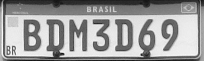

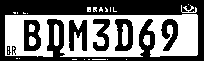

In [75]:
for contorno in contornos:
    x, y, w, h = cv2.boundingRect(contorno)
    proporcao = float(w)/h
    if proporcao >=3 and proporcao <= 3.5:
        placa = imagem[y:y+h, x:x+w]
        valor, regiao_interesse = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        regiao_interesse = clear_border(regiao_interesse)
        cv2_imshow(placa)
        cv2_imshow(regiao_interesse)

In [76]:
texto = pytesseract.image_to_string(regiao_interesse, lang= 'por', config = config_tesseract)
print(texto)

.BDM3D69



In [77]:
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

<re.Match object; span=(1, 8), match='BDM3D69'>

Regex para o texto da placa: \w{3}\d{1}\w{1}\d{2}

In [78]:
print(texto_extraido.group(0))

BDM3D69
